# PID vs SMC — Net-Distance Keeping under Marine Current Disturbances

Notebook di supporto al paper *"PID vs. Sliding-Mode Control for Net-Distance Keeping
in Aquaculture Cage Inspection"*. Usa direttamente il motore di simulazione headless
in `simulation.core` (nessuna dipendenza ROS2: stessa fisica e stessi controllori dei
nodi ROS2 in `src/simulation/simulation/`, riutilizzati qui per lanciare centinaia di
run in pochi secondi).

**Struttura:**
1. Esperimento singolo (un controllore, un'ampiezza di corrente)
2. Confronto PID vs SMC a parita' di corrente
3. Campagna di robustezza: PID vs SMC al variare dell'ampiezza di corrente
4. Metrica vs ampiezza di corrente (curve di rottura)
5. Soglia di rottura e tabella riassuntiva
6. Grafico riassuntivo finale (per il paper)


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / 'src' / 'simulation'))

from simulation.core.experiment import run_experiment, run_campaign, DEFAULT_GAINS
from simulation.core.storage import build_summary, load_run

RESULTS_DIR = REPO_ROOT / 'results'
FIGURES_DIR = REPO_ROOT / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)

WINDOW = (0.70, 1.50)   # finestra operativa [m], eq. capitolo 1
D_REF = 1.10            # riferimento di distanza [m], centro finestra

plt.rcParams['figure.dpi'] = 110
COLORS = {'PID': '#1f77b4', 'SMC': '#d62728'}


## 1. Esperimento singolo

Scegli un controllore e un'ampiezza di corrente: la corrente e' un gradino (step) diretto
lungo +x, cioe' spinge il ROV *lontano* dalla rete (il caso peggiore per il mantenimento
della distanza, dato che il controllore deve fornire spinta persistente per restare in
finestra). `t_onset` e' l'istante in cui la corrente si attiva.


In [2]:
CONTROLLER = 'PID'          # 'PID' oppure 'SMC'
CURRENT_AMPLITUDE = 0.4     # m/s
DURATION = 40.0             # s
T_ONSET = 5.0                # s

df, metrics = run_experiment(CONTROLLER, CURRENT_AMPLITUDE, duration=DURATION, t_onset=T_ONSET)

for k, v in metrics.items():
    print(f'{k:>18s}: {v}')


     pct_in_window: 95.28632158039511
              rmse: 0.23748884431581166
      min_distance: 0.7780142637215104
     settling_time: 8.88
    control_effort: 1076.5995818247063
        controller: PID
 current_amplitude: 0.4
 current_direction: 0.0
           profile: step


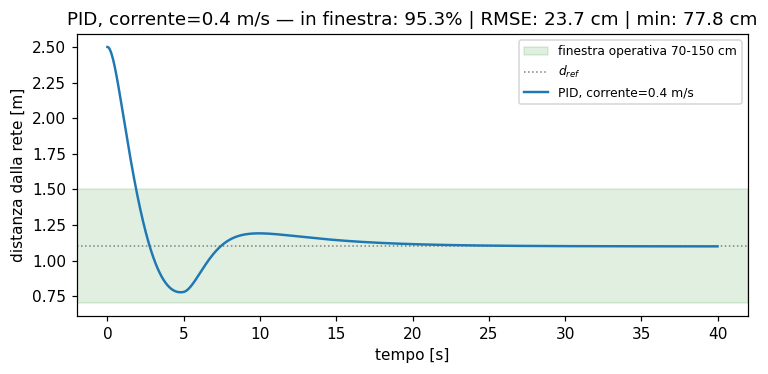

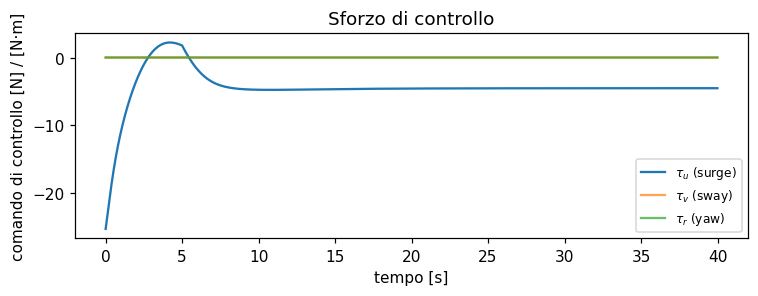

In [3]:
def plot_run(df, metrics, title, window=WINDOW, d_ref=D_REF, ax=None, color=None):
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.axhspan(window[0], window[1], color='green', alpha=0.12, label='finestra operativa 70-150 cm')
    ax.axhline(d_ref, color='gray', linestyle=':', linewidth=1, label='$d_{ref}$')
    ax.plot(df['t'].to_numpy(), df['distance'].to_numpy(), color=color or 'k', linewidth=1.6, label=title)
    ax.set_xlabel('tempo [s]')
    ax.set_ylabel('distanza dalla rete [m]')
    ax.set_title(f"{title} — in finestra: {metrics['pct_in_window']:.1f}% | "
                 f"RMSE: {metrics['rmse']*100:.1f} cm | min: {metrics['min_distance']*100:.1f} cm")
    ax.legend(loc='upper right', fontsize=8)
    if own_fig:
        fig.tight_layout()
    return ax


plot_run(df, metrics, f'{CONTROLLER}, corrente={CURRENT_AMPLITUDE} m/s', color=COLORS.get(CONTROLLER))
plt.show()

fig, ax = plt.subplots(figsize=(7, 2.8))
t_arr = df['t'].to_numpy()
ax.plot(t_arr, df['tau_u'].to_numpy(), label=r'$\tau_u$ (surge)')
ax.plot(t_arr, df['tau_v'].to_numpy(), label=r'$\tau_v$ (sway)', alpha=0.7)
ax.plot(t_arr, df['tau_r'].to_numpy(), label=r'$\tau_r$ (yaw)', alpha=0.7)
ax.set_xlabel('tempo [s]')
ax.set_ylabel('comando di controllo [N] / [N·m]')
ax.set_title('Sforzo di controllo')
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


## 2. Confronto PID vs SMC a parita' di corrente

Stessa ampiezza di corrente, stesse condizioni iniziali: sovrapponiamo le due risposte
per vedere overshoot, velocita' di convergenza e sforzo di controllo a colpo d'occhio.


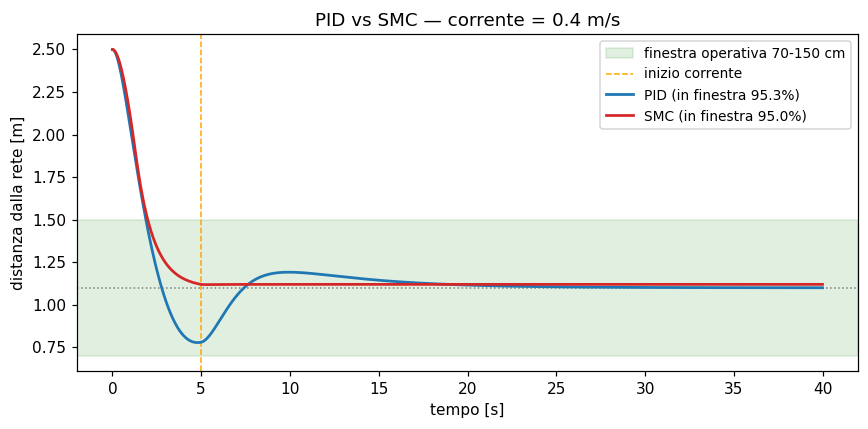

,pct_in_window,rmse,min_distance,settling_time,control_effort
controller,,,,,
PID,95.286322,0.237489,0.778014,8.88,1076.599582
SMC,95.036259,0.233913,1.118669,0.00,1081.127749


In [4]:
COMPARE_AMPLITUDE = 0.4  # m/s

df_pid, m_pid = run_experiment('PID', COMPARE_AMPLITUDE, duration=DURATION, t_onset=T_ONSET)
df_smc, m_smc = run_experiment('SMC', COMPARE_AMPLITUDE, duration=DURATION, t_onset=T_ONSET)

fig, ax = plt.subplots(figsize=(8, 4))
ax.axhspan(WINDOW[0], WINDOW[1], color='green', alpha=0.12, label='finestra operativa 70-150 cm')
ax.axhline(D_REF, color='gray', linestyle=':', linewidth=1)
ax.axvline(T_ONSET, color='orange', linestyle='--', linewidth=1, label='inizio corrente')
ax.plot(df_pid['t'].to_numpy(), df_pid['distance'].to_numpy(), color=COLORS['PID'], linewidth=1.8,
        label=f"PID (in finestra {m_pid['pct_in_window']:.1f}%)")
ax.plot(df_smc['t'].to_numpy(), df_smc['distance'].to_numpy(), color=COLORS['SMC'], linewidth=1.8,
        label=f"SMC (in finestra {m_smc['pct_in_window']:.1f}%)")
ax.set_xlabel('tempo [s]')
ax.set_ylabel('distanza dalla rete [m]')
ax.set_title(f'PID vs SMC — corrente = {COMPARE_AMPLITUDE} m/s')
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'pid_vs_smc_single_current.png', dpi=300)
plt.show()

pd.DataFrame([m_pid, m_smc]).set_index('controller')[
    ['pct_in_window', 'rmse', 'min_distance', 'settling_time', 'control_effort']]


## 3. Campagna di robustezza: PID vs SMC al variare dell'ampiezza di corrente

Ogni run dura 120 s, con la corrente attivata a `t_onset=10s` e mantenuta costante fino
alla fine: cosi' la finestra di valutazione e' dominata dal comportamento a regime sotto
disturbo persistente, non dal solo transitorio di avvicinamento iniziale. Ogni run viene
salvato su disco in `results/` (parametri, metriche, serie temporale) tramite
`simulation.core.storage`, cosi' la campagna si puo' ricaricare senza rilanciarla.


In [5]:
AMPLITUDES = np.round(np.arange(0.0, 1.31, 0.1), 2).tolist()
CAMPAIGN_DURATION = 120.0
CAMPAIGN_T_ONSET = 10.0

summary = run_campaign(
    controllers=['PID', 'SMC'],
    current_amplitudes=AMPLITUDES,
    results_dir=RESULTS_DIR,
    duration=CAMPAIGN_DURATION,
    t_onset=CAMPAIGN_T_ONSET,
)

print(f'{len(summary)} run salvati in {RESULTS_DIR}')
summary.sort_values(['controller', 'current_amplitude']).head(10)


28 run salvati in /home/paolo/Downloads/track2/results


,run_id,controller,current_amplitude,profile,duration,t_onset,pct_in_window,rmse,min_distance,settling_time,control_effort,current_direction
0,PID_step_amp0.00,PID,0.0,step,120.0,10.0,98.429036,0.139424,0.778014,3.69,380.992083,0.0
1,PID_step_amp0.10,PID,0.1,step,120.0,10.0,98.429036,0.138996,0.778014,1.61,418.178952,0.0
2,PID_step_amp0.20,PID,0.2,step,120.0,10.0,98.429036,0.138818,0.778014,0.95,638.375959,0.0
3,PID_step_amp0.30,PID,0.3,step,120.0,10.0,98.429036,0.139626,0.778014,6.78,1270.215959,0.0
4,PID_step_amp0.40,PID,0.4,step,120.0,10.0,98.429036,0.142394,0.778014,10.66,2631.052218,0.0
5,PID_step_amp0.50,PID,0.5,step,120.0,10.0,98.429036,0.148227,0.778014,13.21,5127.527992,0.0
6,PID_step_amp0.60,PID,0.6,step,120.0,10.0,98.429036,0.158169,0.778014,15.01,9256.168337,0.0
7,PID_step_amp0.70,PID,0.7,step,120.0,10.0,95.720477,0.173001,0.778014,16.33,15603.986938,0.0
8,PID_step_amp0.80,PID,0.8,step,120.0,10.0,93.070256,0.225879,0.778014,NaN,24712.677679,0.0
9,PID_step_amp0.90,PID,0.9,step,120.0,10.0,90.753396,0.365945,0.778014,NaN,37284.052765,0.0


## 4. Metrica vs ampiezza di corrente (curve di rottura)

Una curva per ciascuna delle 5 metriche, PID vs SMC: il punto in cui le curve si
allontanano/degradano e' la soglia di rottura di ciascun controllore.


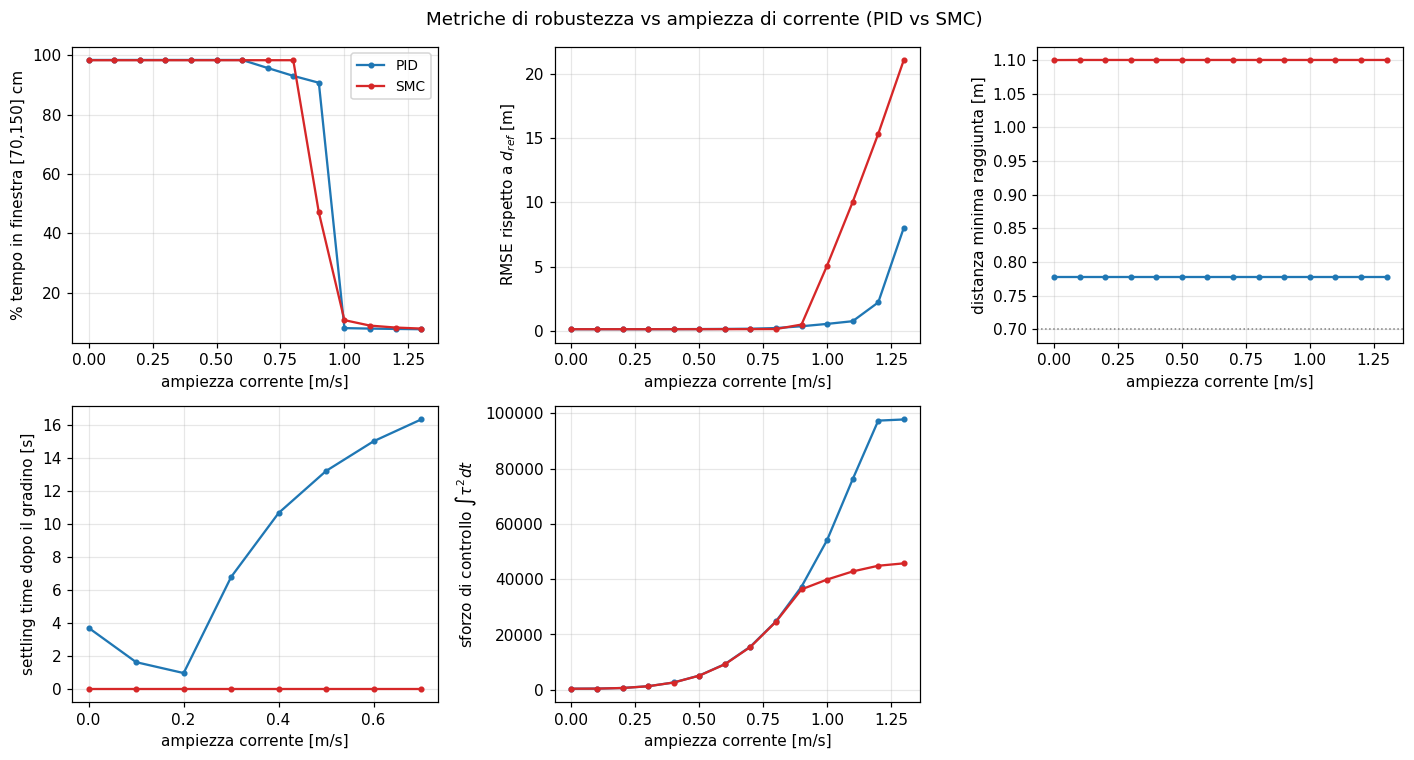

In [6]:
METRIC_LABELS = {
    'pct_in_window': '% tempo in finestra [70,150] cm',
    'rmse': 'RMSE rispetto a $d_{ref}$ [m]',
    'min_distance': 'distanza minima raggiunta [m]',
    'settling_time': 'settling time dopo il gradino [s]',
    'control_effort': r'sforzo di controllo $\int \tau^2 dt$',
}

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()

for ax, (metric, label) in zip(axes, METRIC_LABELS.items()):
    for ctrl in ['PID', 'SMC']:
        sub = summary[summary['controller'] == ctrl].sort_values('current_amplitude')
        ax.plot(sub['current_amplitude'].to_numpy(), sub[metric].to_numpy(), marker='o', markersize=3,
                color=COLORS[ctrl], label=ctrl)
    ax.set_xlabel('ampiezza corrente [m/s]')
    ax.set_ylabel(label)
    ax.grid(alpha=0.3)

axes[0].legend(fontsize=9)
axes[2].axhline(WINDOW[0], color='gray', linestyle=':', linewidth=1)
axes[-1].axis('off')
fig.suptitle('Metriche di robustezza vs ampiezza di corrente (PID vs SMC)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'metrics_vs_current.png', dpi=300)
plt.show()


## 5. Soglia di rottura e tabella riassuntiva

Definiamo la **soglia di rottura pratica** come la prima ampiezza di corrente (nel set
testato) per cui il controllore scende sotto il 95% di tempo trascorso nella finestra
operativa. E' una soglia discreta (dipende dalla granularita' di `AMPLITUDES`): la curva
della sezione 4 mostra l'andamento completo per un'analisi piu' fine.


In [7]:
def breakdown_threshold(summary, controller, pct_threshold=95.0):
    sub = summary[summary['controller'] == controller].sort_values('current_amplitude')
    below = sub[sub['pct_in_window'] < pct_threshold]
    return float(below['current_amplitude'].iloc[0]) if len(below) else None


thresholds = {ctrl: breakdown_threshold(summary, ctrl) for ctrl in ['PID', 'SMC']}
print('Soglie di rottura (pct_in_window < 95%):', thresholds)

summary_table = summary.sort_values(['controller', 'current_amplitude'])[
    ['controller', 'current_amplitude', 'pct_in_window', 'rmse', 'min_distance',
     'settling_time', 'control_effort']
].round(3)
summary_table


Soglie di rottura (pct_in_window < 95%): {'PID': 0.8, 'SMC': 0.9}


,controller,current_amplitude,pct_in_window,rmse,min_distance,settling_time,control_effort
0,PID,0.0,98.429,0.139,0.778,3.69,380.992
1,PID,0.1,98.429,0.139,0.778,1.61,418.179
2,PID,0.2,98.429,0.139,0.778,0.95,638.376
3,PID,0.3,98.429,0.140,0.778,6.78,1270.216
4,PID,0.4,98.429,0.142,0.778,10.66,2631.052
5,PID,0.5,98.429,0.148,0.778,13.21,5127.528
6,PID,0.6,98.429,0.158,0.778,15.01,9256.168
7,PID,0.7,95.720,0.173,0.778,16.33,15603.987
8,PID,0.8,93.070,0.226,0.778,NaN,24712.678
9,PID,0.9,90.753,0.366,0.778,NaN,37284.053


In [8]:
# Tabella pronta per il paper (LaTeX)
latex_table = summary_table[summary_table['current_amplitude'].isin(
    [0.0, 0.3, 0.6, 0.9, 1.2])].to_latex(index=False, float_format='%.3f')
print(latex_table)


\begin{tabular}{lrrrrrr}
\toprule
controller & current_amplitude & pct_in_window & rmse & min_distance & settling_time & control_effort \\
\midrule
PID & 0.000 & 98.429 & 0.139 & 0.778 & 3.690 & 380.992 \\
PID & 0.300 & 98.429 & 0.140 & 0.778 & 6.780 & 1270.216 \\
PID & 0.600 & 98.429 & 0.158 & 0.778 & 15.010 & 9256.168 \\
PID & 0.900 & 90.753 & 0.366 & 0.778 & NaN & 37284.053 \\
PID & 1.200 & 7.792 & 2.219 & 0.778 & NaN & 97349.072 \\
SMC & 0.000 & 98.346 & 0.135 & 1.100 & 0.000 & 368.168 \\
SMC & 0.300 & 98.346 & 0.135 & 1.100 & 0.000 & 1257.837 \\
SMC & 0.600 & 98.346 & 0.140 & 1.100 & 0.000 & 9189.294 \\
SMC & 0.900 & 47.046 & 0.498 & 1.100 & NaN & 36308.581 \\
SMC & 1.200 & 8.259 & 15.321 & 1.100 & NaN & 44853.650 \\
\bottomrule
\end{tabular}



## 6. Grafico riassuntivo finale (per il paper)

`% tempo in finestra` vs ampiezza di corrente per entrambi i controllori, con le soglie
di rottura evidenziate: e' il grafico che risponde direttamente alla research question.


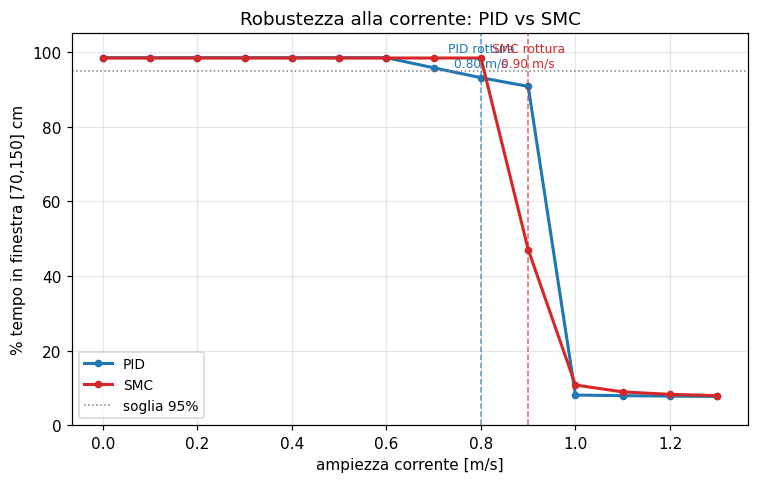

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for ctrl in ['PID', 'SMC']:
    sub = summary[summary['controller'] == ctrl].sort_values('current_amplitude')
    ax.plot(sub['current_amplitude'].to_numpy(), sub['pct_in_window'].to_numpy(), marker='o', markersize=4,
            color=COLORS[ctrl], linewidth=2, label=ctrl)
    thr = thresholds[ctrl]
    if thr is not None:
        ax.axvline(thr, color=COLORS[ctrl], linestyle='--', linewidth=1, alpha=0.7)
        ax.annotate(f'{ctrl} rottura\n{thr:.2f} m/s', xy=(thr, 96),
                    color=COLORS[ctrl], fontsize=8, ha='center')

ax.axhline(95, color='gray', linestyle=':', linewidth=1, label='soglia 95%')
ax.set_xlabel('ampiezza corrente [m/s]')
ax.set_ylabel('% tempo in finestra [70,150] cm')
ax.set_title('Robustezza alla corrente: PID vs SMC')
ax.set_ylim(0, 105)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'breakdown_summary.png', dpi=300)
plt.show()
